# Task 2: Where to place up to 12 extra vehicles

**Goal.** Choose where to add up to 12 vehicles (VSAV or FPT) across the 30 centres. Three objectives, all to
minimise: P90 of SAP response times, unanswered fires, vehicles bought. Deliver a Pareto front and 3 or 4 plans.

**Rules.**

- The simulator is noisy, so every result is a **mean of several replays with its 95% interval**.
- **2000 replays** for the whole test. **600 are kept for Act 3**: the code refuses any call that would use them.
- Every simulator answer is cached in `results/simulation_runs.csv`, so this notebook re-runs for free.

**Method.** A simulation-optimisation loop, the same family of methods as Selene Cerna Ñahuis's FEMTO-ST thesis
(2022, Doubs fire service: load simulator, ambulance redeployment, new centre). The three-objective set-up is this
test's own simplified version, not her problem.

In [1]:
import pandas as pd
import helpers as h
import figures as fg
import simulation as sim

RESERVE = 600  # replays kept for Act 3
pd.set_option("display.max_colwidth", None)
raw = h.load_raw()
iv = h.build_interventions(raw)
centres = raw["centres"]["code_cis"].tolist()

## 1. Can the simulator be trusted, and how noisy is it?

Baseline (no extra vehicle), then 12 extra VSAV and 12 extra FPT, placed where 2025 shows each type was short.

In [2]:
short = h.shortage_by_centre(raw, iv)  # 2025 shortage per centre and vehicle type
V12 = {c: {"VSAV": 1} for c in short["VSAV"].nlargest(12).index}
F12 = {c: {"FPT": 1} for c in short["FPT"].nlargest(12).index}
base_1 = sim.evaluate({}, 30, tag="A_noise", reserve=RESERVE)
print("2025 data (Task 1): P90 SAP 25.51 min, 290 unanswered fires")
sim.summary({"simulator, no extra vehicle": base_1,
             "+12 VSAV": sim.evaluate(V12, 10, tag="A_noise", reserve=RESERVE),
             "+12 FPT": sim.evaluate(F12, 10, tag="A_noise", reserve=RESERVE)})

2025 data (Task 1): P90 SAP 25.51 min, 290 unanswered fires


,vehicles,replays,P90 SAP (min),unanswered fires
"simulator, no extra vehicle",0,30,25.58 ± 0.07,298 ± 5
+12 VSAV,12,10,21.54 ± 0.15,302 ± 14
+12 FPT,12,10,25.60 ± 0.21,3 ± 2


- **The simulator matches 2025** (25.58 min and 298 fires against 25.51 and 290). One replay varies by about
  0.2 min and 15 fires, so single replays are never used.
- **VSAVs only move the P90, FPTs only move fires.** Same as in the data, where SAP is always answered first by a
  VSAV and a fire by an FPT. So the problem splits in two: VSAVs for the P90, FPTs for fires.

## 2. One extra vehicle at a time

Every centre gets +1 VSAV, then +1 FPT (60 runs, 3 replays each). Top 5 of each:

In [3]:
screen = pd.DataFrame([{"type": t, "centre": c, **sim.evaluate({c: {t: 1}}, 3, tag="B_screen", reserve=RESERVE)}
                       for t in sim.TYPES for c in centres])
vs = screen[screen["type"] == "VSAV"].set_index("centre")
fp = screen[screen["type"] == "FPT"].set_index("centre")
pd.concat([vs["p90"].nsmallest(5).round(2).reset_index().add_prefix("+1 VSAV: "),
           fp["inc"].nsmallest(5).round(0).reset_index().add_prefix("+1 FPT: ")], axis=1)

,+1 VSAV: centre,+1 VSAV: p90,+1 FPT: centre,+1 FPT: inc
0,CIS10,24.75,CIS14,118.0
1,CIS08,24.75,CIS25,140.0
2,CIS27,24.86,CIS12,144.0
3,CIS22,24.88,CIS24,144.0
4,CIS16,24.88,CIS11,152.0


- **One FPT at CIS14 cuts unanswered fires from about 290 to 120.** The west volunteer centres (CIS14, 25, 12, 24,
  11) have no FPT today, so their fires wait for one from far away.
- **One VSAV is worth at most 0.8 min**, best at CIS10 (a backup centre) or CIS08 (isolated, far south).

**A doubt, checked.** VSAV-only runs averaged 286 fires instead of 298, and CIS02 showed 249. If VSAVs reduced
fires, the split above would be wrong. 40 more replays settle it:

In [4]:
base_2 = sim.evaluate({}, 20, tag="A_recheck", reserve=RESERVE)
six = {c: {"VSAV": 1} for c in vs["inc"].nsmallest(6).index}
base = sim.pool([base_1, base_2])  # reference from now on: 50 replays, gap between calls included
sim.summary({"no extra vehicle, 1st call": base_1, "no extra vehicle, 2nd call": base_2,
             "+1 VSAV at CIS02, again": sim.evaluate({"CIS02": {"VSAV": 1}}, 10, tag="A_recheck", reserve=RESERVE),
             "+6 VSAV, lowest fire counts": sim.evaluate(six, 10, tag="A_recheck", reserve=RESERVE),
             "no extra vehicle, pooled": base})

,vehicles,replays,P90 SAP (min),unanswered fires
"no extra vehicle, 1st call",0,30,25.58 ± 0.07,298 ± 5
"no extra vehicle, 2nd call",0,20,25.61 ± 0.10,284 ± 8
"+1 VSAV at CIS02, again",1,10,25.26 ± 0.16,286 ± 13
"+6 VSAV, lowest fire counts",6,10,23.28 ± 0.10,282 ± 19
"no extra vehicle, pooled",0,50,25.59 ± 0.06,292 ± 5


- **VSAVs do not reduce fires** (286 and 282 fires, as without them). The split holds.
- **Fire counts are noisier than one call shows**: two identical calls differ by 15. So gaps under about 25 fires
  between short runs are treated as noise. The P90 is stable (0.03 min apart).

## 3. Best placement, one vehicle at a time

Add the next vehicle where it helps most, re-testing only the 5 most promising centres each time (3 replays). Then
replay each step 10 times, fresh, because the search flatters its own picks.

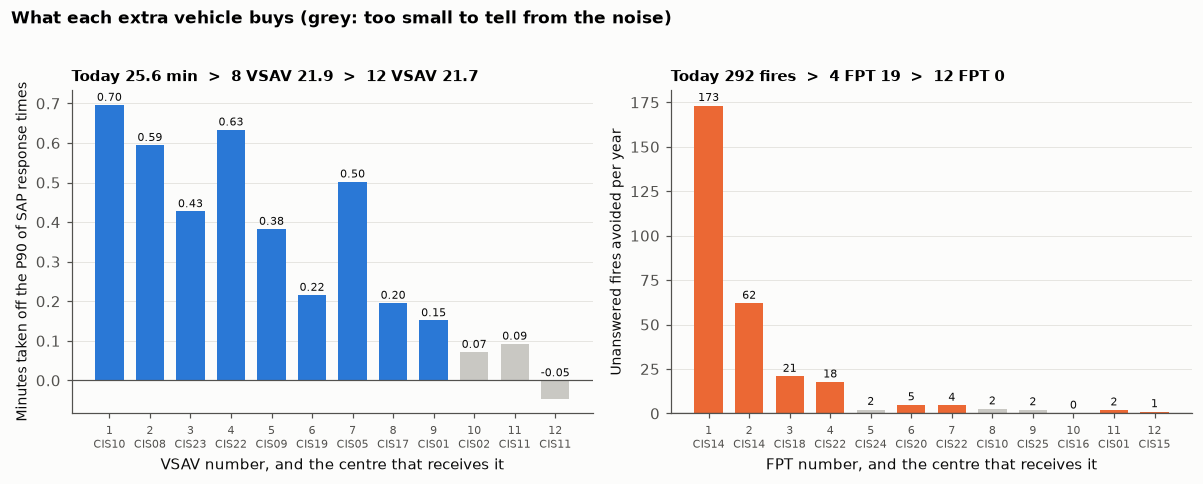

In [5]:
vsav_path = sim.greedy("VSAV", "p90", base["p90"] - vs["p90"], base, RESERVE)
fpt_path = sim.greedy("FPT", "inc", base["inc"] - fp["inc"], base, RESERVE)
curve_v, curve_f = sim.confirm(vsav_path, "p90", base, RESERVE), sim.confirm(fpt_path, "inc", base, RESERVE)
pd.concat([curve_v.round(2).add_prefix("VSAV "), curve_f.round(1).add_prefix("FPT ")], axis=1).to_csv(
    h.RESULTS / "reinforcement_curves.csv")
fg.vehicle_gains(curve_v, curve_f)

- **Four FPTs do the work on fires:** 292 to 19 a year (minus 94%). Two at CIS14, then CIS18, then CIS22.
  Each FPT after that saves fewer than 5 fires.
- **VSAVs pay steadily up to about 8:** around half a minute each, 25.6 to 21.9 min. After that, each one is inside
  the noise.
- **Noise caught twice:** fresh replays were up to 0.4 min and 8 fires worse than the search said. An early
  "stop below 10 fires" rule had stopped FPTs at 5 on a flattered 9 (really 17), so it was removed.

## 4. The Pareto front

Any split of v VSAV and f FPT is scored from the two curves above (each objective depends on one type only):
91 splits of at most 12 vehicles.

90 of 91 splits are on the front (the other one: 12 VSAV, 0 FPT)


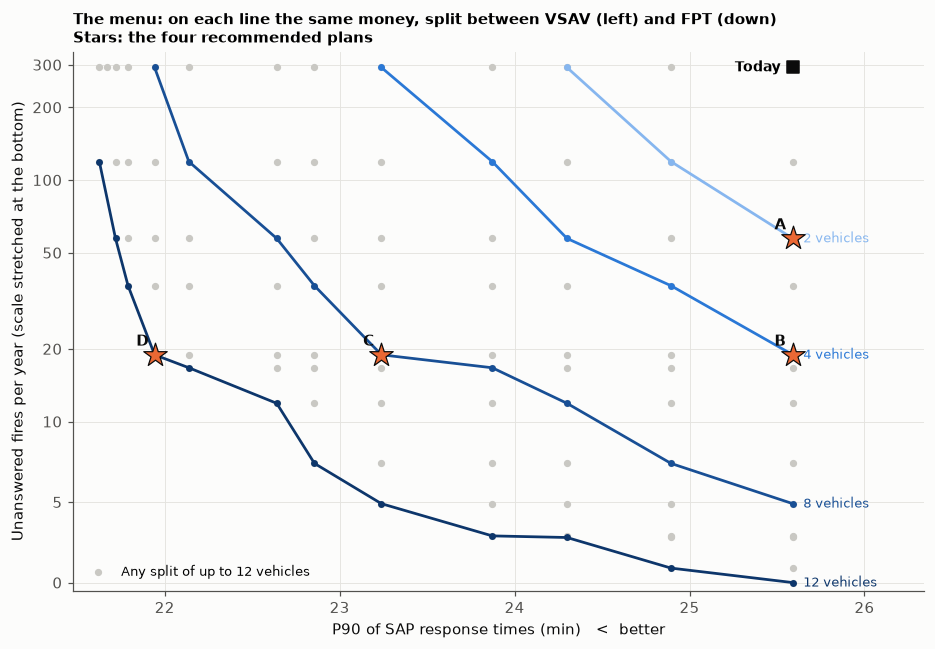

In [6]:
front = pd.DataFrame([{"VSAV": v, "FPT": f, "vehicles": v + f, "p90": curve_v["mean"][v], "inc": curve_f["mean"][f]}
                      for v in curve_v.index for f in curve_f.index if v + f <= sim.MAX_VEHICLES])
front["pareto"] = sim.pareto_mask(front[["p90", "inc", "vehicles"]])
front.round(2).to_csv(h.RESULTS / "pareto_front.csv", index=False)
picks = pd.DataFrame([("A", 0, 2), ("B", 0, 4), ("C", 4, 4), ("D", 8, 4)],
                     columns=["label", "VSAV", "FPT"]).merge(front, on=["VSAV", "FPT"])
print(f"{front['pareto'].sum()} of {len(front)} splits are on the front (the other one: 12 VSAV, 0 FPT)")
fg.tradeoff_front(front, picks)

- **Almost every split is on the front:** a cheaper plan is never beaten by a dearer one. Only 12 VSAV and 0 FPT is
  wasteful (the 12th VSAV buys nothing).
- **The front is the menu, not the choice.** Moving along a line trades minutes of P90 for fires, at the same cost.
  That trade-off is the service's call.

## 5. Four recommended plans

Each plan contains the previous one, so the service can buy in stages. FPTs come first: the first FPT saves about
170 fires a year, the first VSAV 0.7 min. Each plan is replayed 20 times as a whole, which also checks the split.

,vehicles,replays,P90 SAP (min),unanswered fires,predicted,where
A,2,20,25.63 ± 0.09,59 ± 4,"25.59 min, 57 fires",FPT: CIS14 x2
B,4,20,25.61 ± 0.10,19 ± 3,"25.59 min, 19 fires","FPT: CIS14 x2, CIS18, CIS22"
C,8,20,23.17 ± 0.07,19 ± 2,"23.24 min, 19 fires","FPT: CIS14 x2, CIS18, CIS22; VSAV: CIS08, CIS10, CIS22, CIS23"
D,12,20,21.96 ± 0.09,19 ± 2,"21.94 min, 19 fires","FPT: CIS14 x2, CIS18, CIS22; VSAV: CIS05, CIS08, CIS09, CIS10, CIS17, CIS19, CIS22, CIS23"


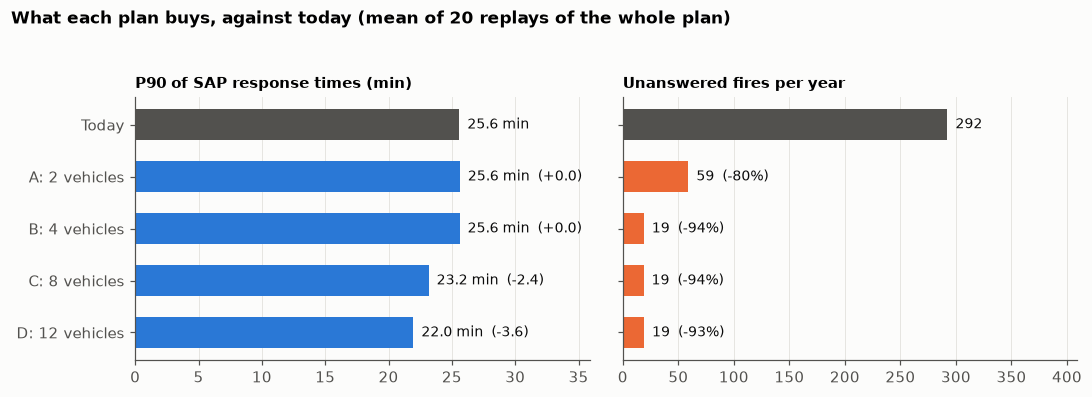

In [7]:
picks["config"] = [sim.combine(vsav_path, fpt_path, v, f) for v, f in zip(picks["VSAV"], picks["FPT"])]
joint = {p.label: sim.evaluate(p.config, 20, tag="E_joint", reserve=RESERVE) for p in picks.itertuples()}
table = sim.summary(joint)
table["predicted"] = [f"{p.p90:.2f} min, {p.inc:.0f} fires" for p in picks.itertuples()]
table["where"] = [sim.describe(c) for c in picks["config"]]
picks["p90"], picks["inc"] = [joint[x]["p90"] for x in picks["label"]], [joint[x]["inc"] for x in picks["label"]]
table.to_csv(h.RESULTS / "recommendations.csv")
fg.plan_scorecard(picks, base)
table

,communes (fires),their 2025 unanswered fires,communes (SAP),their 2025 SAP calls > 20 min,zones
A,15,125,0,0,"Z3: 11, Z4: 4"
B,41,145,0,0,"Z2: 3, Z3: 32, Z4: 6"
C,41,145,40,1784,"Z1: 1, Z2: 11, Z3: 42, Z4: 13"
D,41,145,86,4158,"Z1: 3, Z2: 17, Z3: 63, Z4: 22"


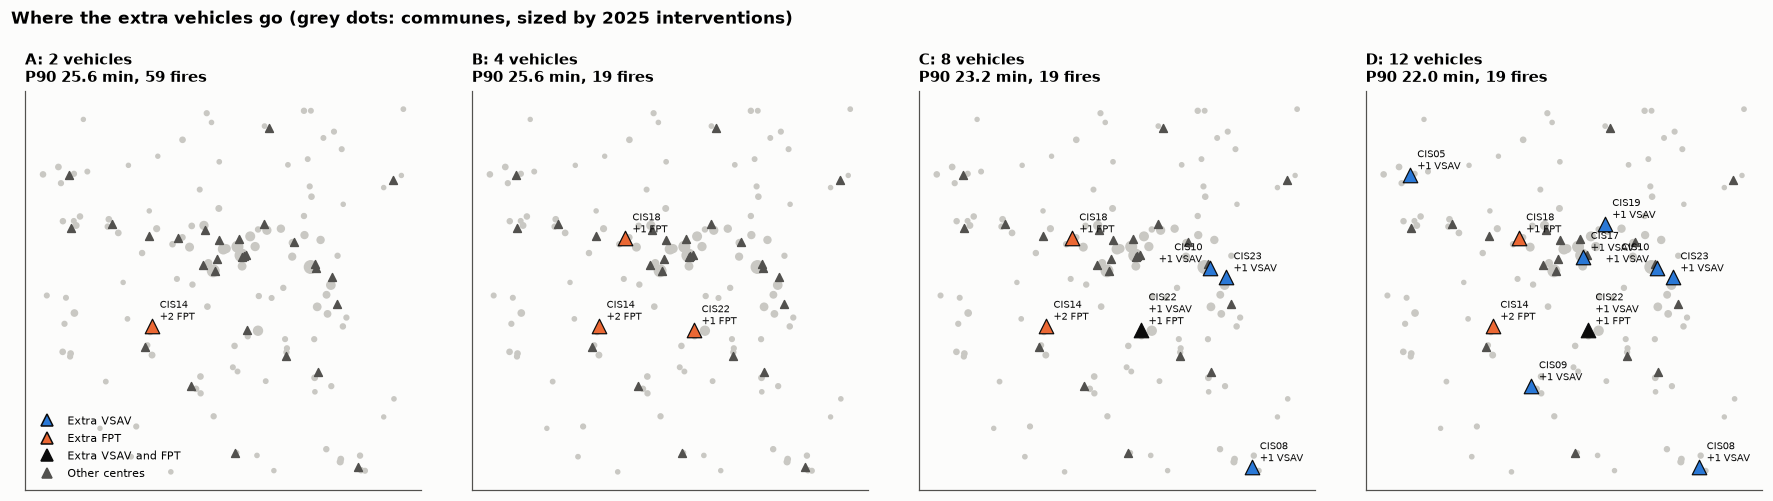

In [8]:
fg.reinforcement_map(raw, picks, iv)
pd.DataFrame({p.label: h.who_benefits(raw, iv, p.config) for p in picks.itertuples()}).T  # 2025: 290 fires, 6005 SAP > 20 min

- **A, 2 vehicles: 2 FPT at CIS14.** Unanswered fires minus 80%, for the west and south-west.
- **B, 4 vehicles: A + 1 FPT at CIS18 and 1 at CIS22.** Fires minus 94% (about one every three weeks). P90 unchanged.
- **C, 8 vehicles: B + 4 VSAV (CIS10, CIS08, CIS23, CIS22).** 2.4 min off the P90: the busy east, the far south.
- **D, 12 vehicles: C + 4 VSAV (CIS09, CIS19, CIS05, CIS17).** 3.6 min off the P90, adding the far west and the
  central towns. Alternative if fires matter more: 6 FPT + 6 VSAV, 7 fewer fires for 0.7 min more.

**Who benefits:** mostly outlying Z3 and Z4 communes, the late ones of Task 1. This is inferred from the plan and
2025 data, as the simulator only gives department totals. B's communes held half of 2025's unanswered fires, yet B
removes 94%: the new FPTs also free the existing ones further out.

## 6. Limits and budget

- Each decision rests on 10 to 20 fresh replays. Combined plans match the curves within noise.
- Greedy search is a good heuristic, not a proof. After 4 FPT and 8 VSAV, other centres would do about as well.
- Vehicles count as equal, but an FPT costs more and needs a larger crew than a VSAV.
- No per-commune output from the simulator, and the replayed year is a variation of 2025, not a forecast.

In [9]:
steps = {"A_noise": "noise and checks", "A_recheck": "re-check after the doubt", "B_screen": "one at a time",
         "C_greedy": "search", "D_confirm": "fresh replays", "E_joint": "final check of the plans"}
used = sim.load_runs().groupby("tag")["n"].sum().reindex(list(steps)).rename(steps).rename("replays")
print(f"Task 2 used {used.sum()} replays, {sim.budget_left()} of 2000 left (600 kept for Act 3).")
used.to_frame().T

Task 2 used 950 replays, 1050 of 2000 left (600 kept for Act 3).


tag,noise and checks,re-check after the doubt,one at a time,search,fresh replays,final check of the plans
replays,50,40,180,360,240,80


## Summary

- **Separable problem.** VSAVs only change the P90, FPTs only change unanswered fires (tested three times).
- **Fires are the cheap win.** 4 FPT cut unanswered fires by 94%. 8 VSAV take 3.6 min off the P90, then gains stop.
- **Plans A to D** (2, 4, 8, 12 vehicles) are nested, confirmed on 20 replays each, and on the Pareto front.
- **Budget.** 950 replays used, 1050 left, 600 of them kept for Act 3.